Размер выборки: N = 50
Уровень шума: sigma = 0.2
Диапазон x: [-2, 4]


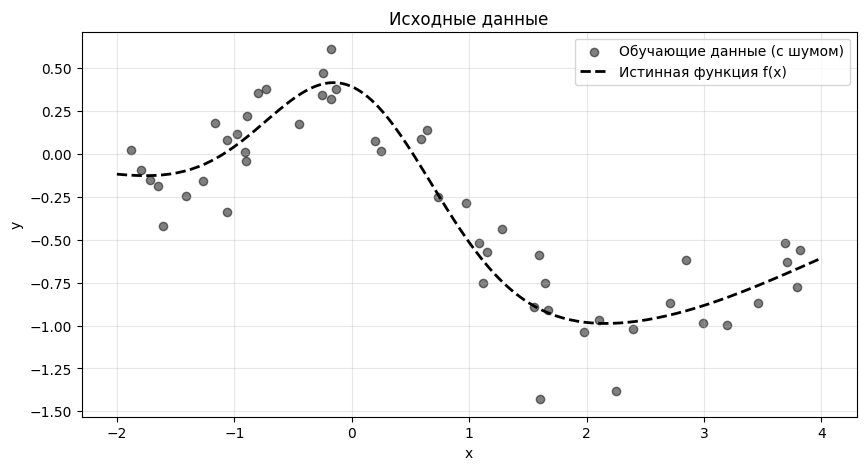

In [ ]:
# Непараметрическая регрессия (Сплайны и GAM)
# Цель: Сравнить полиномиальную регрессию, B-сплайны, сглаживающие сплайны и GAD

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
from scipy.interpolate import LSQUnivariateSpline, UnivariateSpline
from pygam import LinearGAM, s
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
N, sigma = 50, 0.2
x_min, x_max = -2, 4

def f_true(x):
    return np.exp(-x**2) - np.exp(-(x-2)**2 / 8)

X = np.sort(np.random.uniform(x_min, x_max, N))
y = f_true(X) + np.random.normal(0, sigma, N)

X_test = np.linspace(x_min, x_max, 200)
y_test_true = f_true(X_test)

print(f"Размер выборки: N = {N}")
print(f"Уровень шума: sigma = {sigma}")
print(f"Диапазон x: [{x_min}, {x_max}]")

# Визуализация данных
plt.figure(figsize=(10, 5))
plt.scatter(X, y, color='black', alpha=0.5, label='Обучающие данные (с шумом)')
plt.plot(X_test, y_test_true, 'k--', lw=2, label='Истинная функция f(x)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Исходные данные')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
print("ПОЛИНОМИАЛЬНАЯ РЕГРЕССИЯ (Ridge)")

degrees = np.arange(1, 16)
best_poly = None
best_deg = 1
min_cv_mse = float('inf')

for deg in degrees:
    model = make_pipeline(
        PolynomialFeatures(deg),
        RidgeCV(alphas=np.logspace(-6, 2, 20))
    )
    scores = -cross_val_score(model, X.reshape(-1, 1), y, 
                               cv=5, scoring='neg_mean_squared_error')
    cv_mse = np.mean(scores)
    
    if cv_mse < min_cv_mse:
        min_cv_mse = cv_mse
        best_deg = deg
        best_poly = model.fit(X.reshape(-1, 1), y)

print(f"Оптимальная степень полинома: {best_deg}")
print(f"CV MSE: {min_cv_mse:.6f}")

# Предсказание
y_pred_poly = best_poly.predict(X_test.reshape(-1, 1))
mse_poly = mean_squared_error(y_test_true, y_pred_poly)
print(f"MSE на тестовой сетке: {mse_poly:.6f}")

ПОЛИНОМИАЛЬНАЯ РЕГРЕССИЯ (Ridge)
Оптимальная степень полинома: 1
CV MSE: 0.236550
MSE на тестовой сетке: 0.097969


In [5]:
print("B-СПЛАЙНЫ")

#Сплайн с фиксированными узлами (без сглаживания)
internal_knots = np.linspace(x_min + 0.5, x_max - 0.5, 4)
spline_fixed = LSQUnivariateSpline(X, y, internal_knots, k=3)
y_pred_fixed = spline_fixed(X_test)
mse_fixed = mean_squared_error(y_test_true, y_pred_fixed)
df_fixed = len(internal_knots) + 4

print(f"Фиксированные узлы (без сглаживания):")
print(f"  Узлы: {internal_knots.round(2)}")
print(f"  Степени свободы: {df_fixed}")
print(f"  MSE: {mse_fixed:.6f}")

# Сплайн с фиксированными узлами (со сглаживанием)
s_values = np.logspace(-2, 2, 20)
kf = KFold(n_splits=5)
best_s = 0
min_cv_s = float('inf')

for s_val in s_values:
    cv_scores = []
    for train_idx, val_idx in kf.split(X):
        try:
            tmp_spline = UnivariateSpline(X[train_idx], y[train_idx], s=s_val)
            pred = tmp_spline(X[val_idx])
            cv_scores.append(mean_squared_error(y[val_idx], pred))
        except:
            continue
    if cv_scores and np.mean(cv_scores) < min_cv_s:
        min_cv_s = np.mean(cv_scores)
        best_s = s_val

spline_smooth = UnivariateSpline(X, y, s=best_s)
y_pred_smooth = spline_smooth(X_test)
mse_smooth = mean_squared_error(y_test_true, y_pred_smooth)
df_smooth = len(spline_smooth.get_knots()) + 4

print(f"\nСглаживающий сплайн (фиксированные узлы):")
print(f"  Оптимальный параметр s: {best_s:.4f}")
print(f"  Степени свободы: {df_smooth}")
print(f"  MSE: {mse_smooth:.6f}")

#Сглаживающий сплайн (узлы = все точки X)
spline_auto = UnivariateSpline(X, y, s=N * (sigma**2))
y_pred_auto = spline_auto(X_test)
mse_auto = mean_squared_error(y_test_true, y_pred_auto)
df_auto = len(spline_auto.get_knots()) + 4

print(f"\nСглаживающий сплайн (узлы = X):")
print(f"  Параметр s: {N * (sigma**2):.2f}")
print(f"  Степени свободы: {df_auto}")
print(f"  MSE: {mse_auto:.6f}")

B-СПЛАЙНЫ
Фиксированные узлы (без сглаживания):
  Узлы: [-1.5   0.17  1.83  3.5 ]
  Степени свободы: 8
  MSE: 0.012668

Сглаживающий сплайн (фиксированные узлы):
  Оптимальный параметр s: 1.2743
  Степени свободы: 23
  MSE: 0.011353

Сглаживающий сплайн (узлы = X):
  Параметр s: 2.00
  Степени свободы: 9
  MSE: 0.014051


ВИЗУАЛИЗАЦИЯ БАЗИСНЫХ ФУНКЦИЙ B-СПЛАЙНА


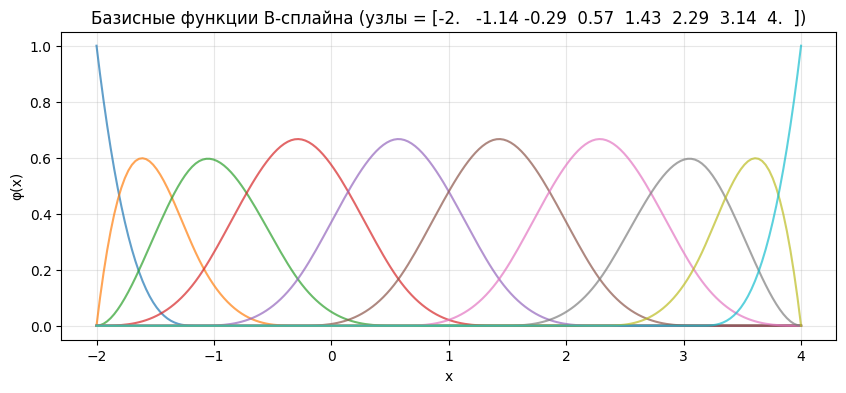

In [6]:
print("ВИЗУАЛИЗАЦИЯ БАЗИСНЫХ ФУНКЦИЙ B-СПЛАЙНА")

from scipy.interpolate import BSpline

def plot_basis(knots, x_range):
    """Визуализирует базисные функции B-сплайна 3-го порядка"""
    t = np.concatenate(([knots[0]]*3, knots, [knots[-1]]*3))
    n_basis = len(t) - 4
    
    plt.figure(figsize=(10, 4))
    for i in range(n_basis):
        coeffs = np.zeros(n_basis)
        coeffs[i] = 1
        b_spl = BSpline(t, coeffs, 3)
        plt.plot(x_range, b_spl(x_range), alpha=0.7)
    
    plt.title(f"Базисные функции B-сплайна (узлы = {knots.round(2)})")
    plt.xlabel('x')
    plt.ylabel('φ(x)')
    plt.grid(True, alpha=0.3)
    plt.show()

# Используем 8 равномерно распределённых узлов
knots_vis = np.linspace(x_min, x_max, 8)
plot_basis(knots_vis, X_test)

In [7]:
print("GAM (ОБОБЩЁННАЯ АДДИТИВНАЯ МОДЕЛЬ)")

gam = LinearGAM(s(0, n_splines=25)).gridsearch(X.reshape(-1, 1), y)
y_pred_gam = gam.predict(X_test)
mse_gam = mean_squared_error(y_test_true, y_pred_gam)

if hasattr(gam, 'edf_'):
    df_gam = np.sum(gam.edf_)
else:
    df_gam = 25

print(f"GAM (pygam):")
print(f"  Эффективные степени свободы: {df_gam:.1f}")
print(f"  MSE: {mse_gam:.6f}")

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


GAM (ОБОБЩЁННАЯ АДДИТИВНАЯ МОДЕЛЬ)
GAM (pygam):
  Эффективные степени свободы: 25.0
  MSE: 0.004973


СРАВНЕНИЕ ВСЕХ МЕТОДОВ
Метод                     | MSE        | df    
---------------------------------------------
Ridge Polynomial          | 0.097969 | 2.0
B-Spline (Fixed)          | 0.012668 | 8.0
B-Spline (Smooth)         | 0.011353 | 23.0
Smoothing Spline          | 0.014051 | 9.0
GAM                       | 0.004973 | 25.0


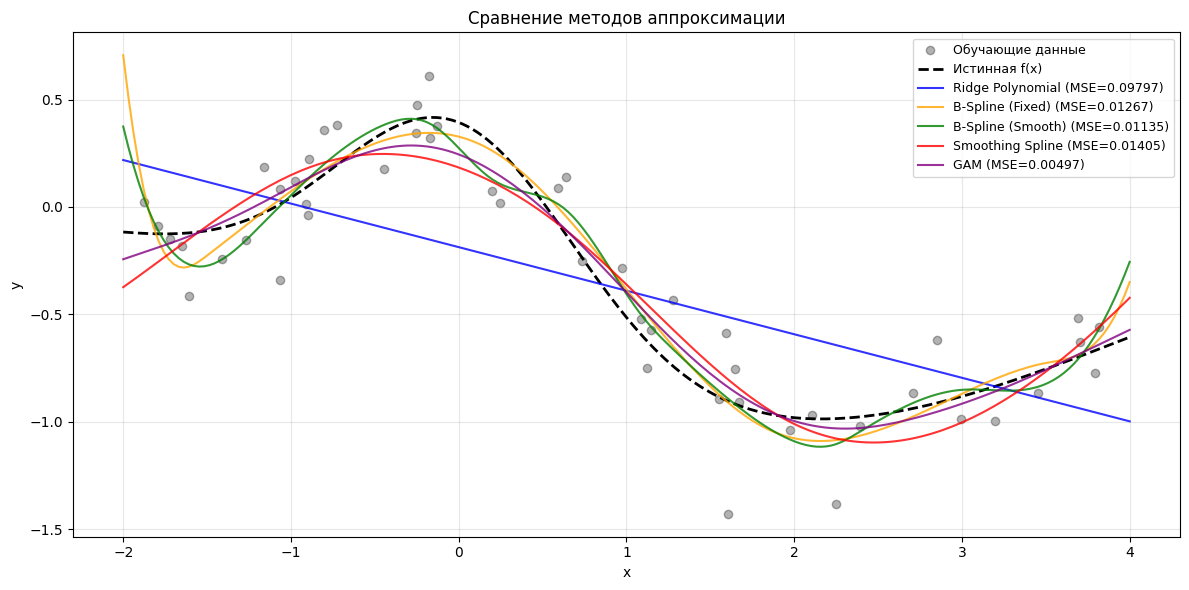

In [9]:
print("СРАВНЕНИЕ ВСЕХ МЕТОДОВ")

results = {
    "Ridge Polynomial": (y_pred_poly, mse_poly, best_deg + 1),
    "B-Spline (Fixed)": (y_pred_fixed, mse_fixed, df_fixed),
    "B-Spline (Smooth)": (y_pred_smooth, mse_smooth, df_smooth),
    "Smoothing Spline": (y_pred_auto, mse_auto, df_auto),
    "GAM": (y_pred_gam, mse_gam, df_gam)
}

print(f"{'Метод':<25} | {'MSE':<10} | {'df':<6}")
print("-" * 45)
for name, (_, mse, df) in results.items():
    print(f"{name:<25} | {mse:.6f} | {df:.1f}")

plt.figure(figsize=(12, 6))
plt.scatter(X, y, color='black', alpha=0.3, label='Обучающие данные')

plt.plot(X_test, y_test_true, 'k--', lw=2, label='Истинная f(x)')

colors = ['blue', 'orange', 'green', 'red', 'purple']
for (name, (pred, _, _)), color in zip(results.items(), colors):
    plt.plot(X_test, pred, label=f'{name} (MSE={results[name][1]:.5f})', 
             color=color, alpha=0.8)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Сравнение методов аппроксимации')
plt.legend(loc='upper right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
print("ИТОГОВЫЕ ВЫВОДЫ")

print("1. Сравнение методов по MSE (относительно истинной функции):")
sorted_results = sorted(results.items(), key=lambda x: x[1][1])
for i, (name, (_, mse, df)) in enumerate(sorted_results, 1):
    print(f"   {i}. {name:<25} MSE={mse:.6f}, df={df:.1f}")

print(f"\n2. Лучший метод: {sorted_results[0][0]}")
print(f"   Почему GAM лучше?")
print("   • GAM адаптивно подбирает степень гладкости для каждого признака")
print("   • Не требует ручного выбора количества узлов")
print("   • Автоматически находит баланс между смещением и дисперсией")

print("\n3. Наблюдения по сплайнам:")
print("   • B-сплайны с фиксированными узлами (без сглаживания) переобучаются")
print("   • Добавление сглаживания (параметр s) улучшает обобщающую способность")
print("   • Сглаживающий сплайн с узлами = X имеет много степеней свободы")


ИТОГОВЫЕ ВЫВОДЫ
1. Сравнение методов по MSE (относительно истинной функции):
   1. GAM                       MSE=0.004973, df=25.0
   2. B-Spline (Smooth)         MSE=0.011353, df=23.0
   3. B-Spline (Fixed)          MSE=0.012668, df=8.0
   4. Smoothing Spline          MSE=0.014051, df=9.0
   5. Ridge Polynomial          MSE=0.097969, df=2.0

2. Лучший метод: GAM
   Почему GAM лучше?
   • GAM адаптивно подбирает степень гладкости для каждого признака
   • Не требует ручного выбора количества узлов
   • Автоматически находит баланс между смещением и дисперсией

3. Наблюдения по сплайнам:
   • B-сплайны с фиксированными узлами (без сглаживания) переобучаются
   • Добавление сглаживания (параметр s) улучшает обобщающую способность
   • Сглаживающий сплайн с узлами = X имеет много степеней свободы
